In [14]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [15]:
# DEVICE + SEED

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)

Using device: cuda


In [16]:
# PATHS

DATA_DIR = "../data/raw/fer2013"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Test dir exists: True


In [17]:
# TRANSFORMS

# ImageNet normalisation (standard for pretrained ResNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [18]:
# DATASETS + TRAIN/VAL SPLIT

base_train = datasets.ImageFolder(
    root=train_dir,
    transform=val_transform
)

val_ratio = 0.15
n_total = len(base_train)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

g = torch.Generator().manual_seed(42)   # new change

train_subset, val_subset = random_split(base_train, [n_train, n_val], generator=g)

train_ids = train_subset.indices
val_ids = val_subset.indices

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=train_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_final = Subset(train_dataset, train_ids)
val_final = Subset(val_dataset, val_ids)

classes = base_train.classes
num_classes = len(classes)

print("Train:", len(train_final))
print("Val:", len(val_final))
print("Test:", len(test_dataset))
print("Classes:", classes)

Train: 24403
Val: 4306
Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [19]:
# DATALOADERS

BATCH_SIZE = 64

train_loader = DataLoader(
    train_final,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_final,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [20]:
# LOAD RESNET18

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model.fc)

Linear(in_features=512, out_features=7, bias=True)


In [21]:
# TRAINING HELPERS

def set_requires_grad(model, flag: bool):
    for p in model.parameters():
        p.requires_grad = flag

def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [22]:
# [A] FREEZE BACKBONE, TRAIN ONLY FC

set_requires_grad(model, False)
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimiser = torch.optim.Adam(model.fc.parameters(), lr=0.001)

EPOCHS_A = 5

best_val_acc = 0
best_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS_A+1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = copy.deepcopy(model.state_dict())

    print(f"[A] Epoch {epoch:02d}/{EPOCHS_A} | train acc {t_acc:.4f} | val acc {v_acc:.4f} | best {best_val_acc:.4f}")

[A] Epoch 01/5 | train acc 0.3516 | val acc 0.3913 | best 0.3913
[A] Epoch 02/5 | train acc 0.4004 | val acc 0.4134 | best 0.4134
[A] Epoch 03/5 | train acc 0.4128 | val acc 0.4111 | best 0.4134
[A] Epoch 04/5 | train acc 0.4149 | val acc 0.4152 | best 0.4152
[A] Epoch 05/5 | train acc 0.4207 | val acc 0.4215 | best 0.4215


In [23]:
# [B] UNFREEZE LAST BLOCK + SMALLER LR

for name, param in model.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

optimiser = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

EPOCHS_B = 8
patience = 3
no_improve = 0

for epoch in range(1, EPOCHS_B+1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(f"[B] Epoch {epoch:02d}/{EPOCHS_B} | train acc {t_acc:.4f} | val acc {v_acc:.4f} | best {best_val_acc:.4f}")

    if no_improve >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_state)
print("Loaded best model. Best val accuracy:", best_val_acc)

[B] Epoch 01/8 | train acc 0.5509 | val acc 0.5985 | best 0.5985
[B] Epoch 02/8 | train acc 0.6343 | val acc 0.6273 | best 0.6273
[B] Epoch 03/8 | train acc 0.6765 | val acc 0.6391 | best 0.6391
[B] Epoch 04/8 | train acc 0.7102 | val acc 0.6475 | best 0.6475
[B] Epoch 05/8 | train acc 0.7417 | val acc 0.6470 | best 0.6475
[B] Epoch 06/8 | train acc 0.7742 | val acc 0.6570 | best 0.6570
[B] Epoch 07/8 | train acc 0.8013 | val acc 0.6600 | best 0.6600
[B] Epoch 08/8 | train acc 0.8314 | val acc 0.6582 | best 0.6600
Loaded best model. Best val accuracy: 0.6600092893636786


In [24]:
# SAVE RESNET MODEL

os.makedirs("../models", exist_ok=True)
MODEL_PATH = "../models/resnet18_best.pt"
torch.save(model.state_dict(), MODEL_PATH)
print("Saved:", MODEL_PATH)

Saved: ../models/resnet18_best.pt


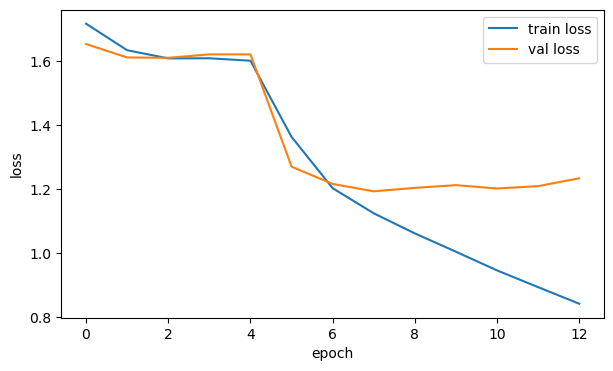

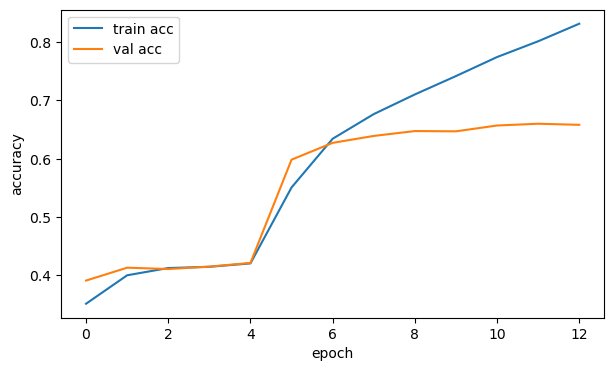

In [25]:
# PLOTS

plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.show()


Test accuracy: 0.6648091390359432
              precision    recall  f1-score   support

       angry     0.6606    0.5324    0.5896       958
     disgust     0.7024    0.5315    0.6051       111
        fear     0.5228    0.4824    0.5018      1024
       happy     0.7962    0.9160    0.8519      1774
     neutral     0.6406    0.6042    0.6219      1233
         sad     0.5094    0.5886    0.5461      1247
    surprise     0.8265    0.7280    0.7742       831

    accuracy                         0.6648      7178
   macro avg     0.6655    0.6262    0.6415      7178
weighted avg     0.6646    0.6648    0.6615      7178



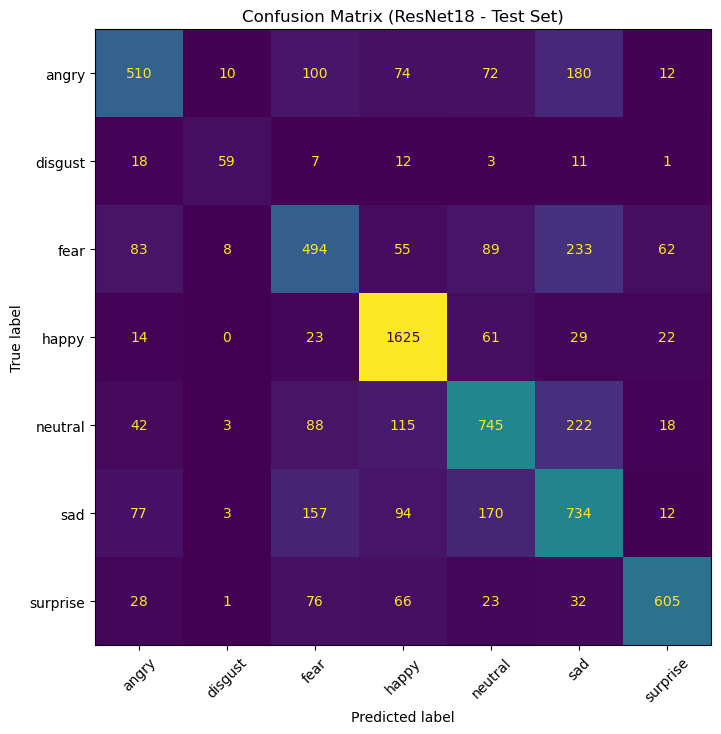

In [26]:
# TEST + CONFUSION MATRIX + REPORT

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Test accuracy:", (y_pred == y_true).mean())

print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (ResNet18 - Test Set)")
plt.show()

Number of misclassified samples: 2406


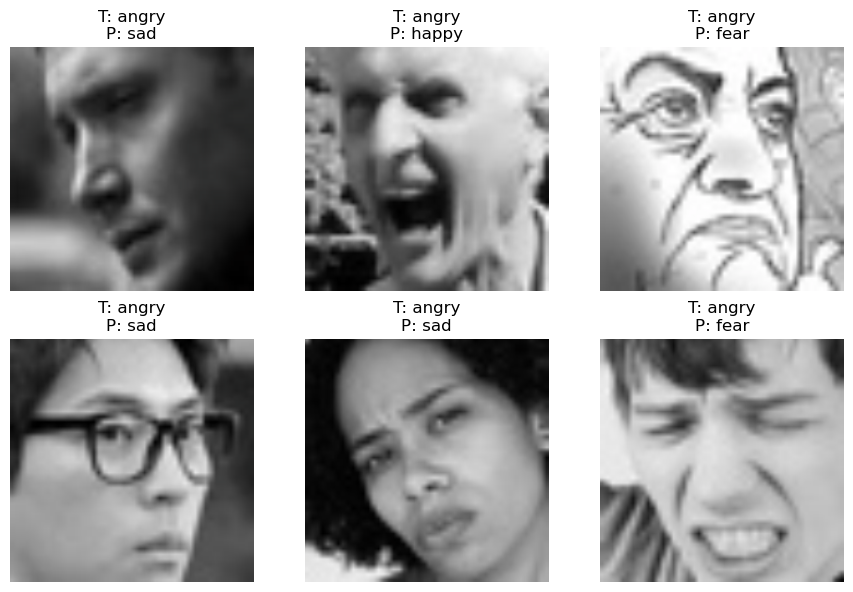

In [27]:
# MISCLASSIFIED EXAMPLES

mis_ids = np.where(y_true != y_pred)[0]
print("Number of misclassified samples:", len(mis_ids))

def denormalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img * std + mean

def show_misclassified(dataset, indices, y_true, y_pred, classes, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(9, 6))
    axes = axes.flatten()

    for i in range(n):
        idx = indices[i]
        img, _ = dataset[idx]
        img = denormalize(img).permute(1, 2, 0).numpy()

        true_label = classes[y_true[idx]]
        pred_label = classes[y_pred[idx]]

        axes[i].imshow(img)
        axes[i].set_title(f"T: {true_label}\nP: {pred_label}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified(test_dataset, mis_ids, y_true, y_pred, classes, n=6)